# **Supervised Learning**  
## Classification of Educational Institutions in Ecuador with $k$-Nearest Neighbors ($k$-NN)
**Author:** Jefferson Gramal & Dario Pomasqui

**Subject:** Artificial Intelligence  
**Topic:** Supervised Learning - $k$-Nearest Neighbors ($k$-NN) Algorithm  
**Dataset:** Administrative Registry of Educational Institutions of Ecuador (MinEduc)  
**Problem Statement:** Classification of institutional funding type (`Fiscal` vs. `Particular`) based on overall enrollment indicators, inclusion of migrant students, and territorial location.

---
### **Notebook Objective**
Implement, justify, and evaluate in a rigorous manner a supervised learning model based on the **$k$-Nearest Neighbors ($k$-NN)** algorithm to predict whether an Ecuadorian educational institution is **Fiscal (public)** or **Particular (private)**.

The full project rubric is addressed:
1. **Origin and comprehensive description of the official database.**
2. **Thematic, statistical, and technical justification of selected and discarded predictor variables.**
3. **Rigorous feature standardization (`StandardScaler`) to avoid dimensional dominance.**
4. **Objective search for the best hyperparameter $k$ via 5-Fold Cross-Validation and error rate curve.**
5. **Fitting, evaluation, and persistence of the model (`joblib`) with visualization of the confusion matrix and correct/error distribution.**
6. **Inference on a new institution and interpretative feature importance analysis using Random Forest.**
---

### **a. Origin of the new database (1 pt)**

* **Issuing Institution:** Ministry of Education of Ecuador (MinEduc).
* **Source Portal:** Official Open Data Platform of the Government of Ecuador ([datosabiertos.gob.ec](https://datosabiertos.gob.ec/) / [educacion.gob.ec](https://educacion.gob.ec/)).
* **Local file used:** `registro-administrativo-historico_2009-2024-inicio.csv` (Consolidated National Administrative Registry).
* **Dataset nature:** This is an **official local database of an administrative-census nature**. **It does not come from synthetic or generic platforms like Kaggle nor toy repositories.**
* **Unit of analysis:** Each row of the dataset corresponds to an official educational institution in Ecuadorian territory during a specific academic year (`Anio_lectivo`). Each institution has a unique national identifier called the **AMIE** code (*Archivo Maestro de Instituciones Educativas* / Master Archive of Educational Institutions).
* **Coverage:** It contains the national census historical record from 2009 to the **2024-2025 Inicio** period (with over 440,000 historical records and 16,152 active institutions for the 2024-2025 academic cycle).

### **b. Description of all dataset variables (1 pt)**

The dataset consists of **27 variables** covering geographic location, administrative regime, teaching staff, and student composition by gender and nationality:

| No. | Variable | Data Type | Detailed Description |
|:---:|:---|:---:|:---|
| 1 | `Anio_lectivo` | Categorical / Text | School census period (e.g., '2024-2025 Inicio'). |
| 2 | `Zona` | Categorical / Text | Administrative educational planning zone of Ecuador (Zones 1 to 9). |
| 3 | `Provincia` | Categorical / Text | Name of the province where the educational institution is located. |
| 4 | `Cod_Provincia` | Numerical (Code) | Official geographic code (INEC) of the province. |
| 5 | `Canton` | Categorical / Text | Name of the canton or municipality of location. |
| 6 | `Cod_Canton` | Numerical (Code) | Official geographic code (INEC) of the canton. |
| 7 | `Parroquia` | Categorical / Text | Name of the urban or rural parish. |
| 8 | `Cod_Parroquia` | Numerical (Code) | Official geographic code (INEC) of the parish. |
| 9 | `Nombre_Institucion` | Text | Registered name of the educational institution. |
| 10 | `AMIE` | Text / Identifier | Master Archive of Educational Institutions code (unique national identifier). |
| 11 | `Tipo_Educacion` | Categorical | Educational modality provided by the school (e.g., Ordinary, Extraordinary). |
| 12 | `Sostenimiento` | Categorical | Source of funding: Fiscal (public), Particular (private), Fiscomisional, or Municipal. |
| 13 | `Area` | Categorical | Territorial setting: Urban or Rural. |
| 14 | `Regimen_Escolar` | Categorical | Academic calendar: Sierra-Amazonía or Costa-Galápagos. |
| 15 | `Jurisdiccion` | Categorical | Linguistic-cultural regime: Hispanic or Bilingual Intercultural. |
| 16 | `Docentes_Femenino` | Numerical (Integer) | Number of female teachers. |
| 17 | `Docentes_Masculino` | Numerical (Integer) | Number of male teachers. |
| 18 | `Total_Docentes` | Numerical (Integer) | Total number of teachers and pedagogical directors in the institution. |
| 19 | `Estudiantes_Femenino` | Numerical (Integer) | Enrollment of female students. |
| 20 | `Estudiantes_Masculino` | Numerical (Integer) | Enrollment of male students. |
| 21 | `Total_Estudiantes` | Numerical (Integer) | Total enrollment registered in the institution during the school year. |
| 22 | `Ecuatoriana` | Numerical (Integer) | Number of students with Ecuadorian nationality. |
| 23 | `Colombiana` | Numerical (Integer) | Enrolled students of Colombian nationality. |
| 24 | `Venezolana` | Numerical (Integer) | Enrolled students of Venezuelan nationality. |
| 25 | `Peruana` | Numerical (Integer) | Enrolled students of Peruvian nationality. |
| 26 | `Otros_Paises_de_America` | Numerical (Integer) | Students from other countries across the American continent. |
| 27 | `Otros_Continentes` | Numerical (Integer) | Students originating from countries on other continents (Europe, Asia, etc.). |

#### **Step 1: Installation of required libraries**
We install the foundational packages for the workflow: `pandas` and `numpy` for matrix manipulation, `scikit-learn` for supervised modeling and cross-validation, and `matplotlib`/`seaborn` for statistical visualization.

In [6]:
# Installation of required packages
%pip install --quiet pandas numpy scikit-learn matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


#### **Step 2: Module imports and graphical configuration**

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Aesthetic configuration of Seaborn and Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

#### **Step 3: Loading the official local dataset**

In [8]:
df_raw = pd.read_csv('../csv/registro-administrativo.csv', sep=';', low_memory=False)


#### **Step 4: Preliminary exploration and filtering of the classification problem**
We filter for the most contemporary academic cycle (**`2024-2025 Inicio`**) and restrict the target variable `Sostenimiento` to the two predominant types in the Ecuadorian system: **`Fiscal` (state public education)** and **`Particular` (self-financed private education)**, creating a **binary supervised classification** problem.

In [9]:
# 1. Filter school period 2024-2025 Inicio
df_current = df_raw[df_raw['Anio_lectivo'] == '2024-2025 Inicio'].copy()

# 2. Filter exclusively funding types 'Fiscal' and 'Particular' (Binary Problem)
df_filtered = df_current[df_current['Sostenimiento'].isin(['Fiscal', 'Particular'])].copy()

print(f"Total institutions for 2024-2025 cycle (Public and Private): {df_filtered.shape[0]:,}")
print("\nDistribution by Funding Type:")
print(df_filtered['Sostenimiento'].value_counts())
print("\nPercentage Distribution:")
print((df_filtered['Sostenimiento'].value_counts(normalize=True) * 100).round(2))

Total institutions for 2024-2025 cycle (Public and Private): 15,436

Distribution by Funding Type:
Sostenimiento
Fiscal        12327
Particular     3109
Name: count, dtype: int64

Percentage Distribution:
Sostenimiento
Fiscal        79.86
Particular    20.14
Name: proportion, dtype: float64


#### **Step 5: Feature preprocessing and encoding of `Area`**
1. We convert quantitative text variables into numeric format using `pd.to_numeric(errors='coerce')` and impute null values with 0.
2. We binary-encode the categorical geographic variable `Area`:
   $$\text{Is\_Urban} = \begin{cases} 1 & \text{if Area} = \text{'Urbana'} \\ 0 & \text{if Area} = \text{'Rural'} \end{cases}$$

In [10]:
# Strict numeric conversion
df_knn = df_filtered.copy()
numeric_cols = ['Total_Estudiantes', 'Venezolana']

for col in numeric_cols:
    df_knn[col] = pd.to_numeric(df_knn[col], errors='coerce').fillna(0)

# Binary encoding of Area: Urbana = 1, Rural = 0
df_knn['Is_Urban'] = (df_knn['Area'] == 'Urbana').astype(int)

# Feature matrix X and target vector y
feature_cols = ['Total_Estudiantes', 'Venezolana', 'Is_Urban']
X = df_knn[feature_cols].copy()
y = df_knn['Sostenimiento'].copy()

print("First 5 rows of feature matrix X:")
print(X.head())
print("\nStatistical summary of predictor features:")
print(X.describe().round(2))

First 5 rows of feature matrix X:
        Total_Estudiantes  Venezolana  Is_Urban
306450                9.0           0         0
306451              142.0           0         0
306452               23.0           0         0
306453             1586.0           1         0
306454               42.0           0         0

Statistical summary of predictor features:
       Total_Estudiantes  Venezolana  Is_Urban
count           15436.00    15436.00  15436.00
mean              247.34        2.88      0.54
std               445.81        9.96      0.50
min                 1.00        0.00      0.00
25%                16.00        0.00      0.00
50%                57.00        0.00      1.00
75%               273.00        1.00      1.00
max              7832.00      215.00      1.00


---
### **c. Justification of variable selection to use in the model (3 pts)**

To train the **$k$-NN** classifier, we define a three-dimensional feature space consisting of:
1. `Total_Estudiantes` (Numerical continuous/integer)
2. `Venezolana` (Numerical continuous/integer)
3. `Is_Urban` (Binary: $1 = \text{Urban}, 0 = \text{Rural}$)

Target Variable: **`Sostenimiento`** $\in \{\text{'Fiscal'}, \text{'Particular'}\}$

#### **1. Thematic and Educational Policy Justification of Selected Variables:**
* **`Total_Estudiantes` (Institutional Operational Scale):** Represents the size of school infrastructure. In Ecuador, massive educational units (macro-schools with over 1,500 to 2,000 students) are almost entirely of **Fiscal** funding, as they address the massive demand for compulsory state-guaranteed education. Conversely, **Particular** (private) schools usually operate in niches with medium and small infrastructures featuring higher teacher-to-student ratios.
* **`Venezolana` (Inclusion and Socioeconomic Vulnerability):** The population in Venezuelan human mobility arriving in Ecuador primarily turns to the **Fiscal** public system due to free education enshrined in the Constitution of the Republic. The presence of Venezuelan students is a strong indicator of inclusive public service; whereas in tuition-charging private schools, foreign enrollment of this origin is substantially lower.
* **`Is_Urban` (Geographic-Economic Location):** Private education (`Particular`) operates predominantly under market logic in consolidated urban centers where families have purchasing power. In dispersed rural areas, educational provision is assumed almost monopolistically by the state's **Fiscal** funding.

#### **2. Justification of Discarded Variables:**
* **Identifiers and Free Text (`AMIE`, `Nombre_Institucion`):** These are unique nominal identifiers lacking algorithmic generalization capability.
* **Detailed Geographic Hierarchy (`Zona`, `Provincia`, `Canton`, `Parroquia`):** High categorical cardinality. Introducing hundreds of *One-Hot* encoded dummy variables would induce the **curse of dimensionality**, severely degrading Euclidean distance calculations in $k$-NN.
* **Teaching Staff (`Total_Docentes`, etc.):** Exhibits near-perfect linear collinearity ($r > 0.95$) with `Total_Estudiantes`, providing redundant information without additional discriminatory power.
* **Gender Subdivisions (`Estudiantes_Femenino`, `Estudiantes_Masculino`):** Their sum is exactly `Total_Estudiantes`; including both would generate strict multicollinearity.

#### **3. Critical Need for Standardization (`StandardScaler`):**
* The kNN algorithm classifies a new observation by calculating the Euclidean distance to training points:
  $$d(p, q) = \sqrt{\sum_{i=1}^{d} (p_i - q_i)^2}$$
* `Total_Estudiantes` ranges from 1 to 7,832 students (scale of thousands), `Venezolana` ranges from 0 to 215 students (scale of tens), and `Is_Urban` is a binary variable with values in $\{0, 1\}$.
* Without standardization, a difference of 100 students in enrollment would contribute $(100)^2 = 10,000$ to distance calculation, whereas the difference between being rural or urban would contribute merely $(1 - 0)^2 = 1$. Consequently, **school size would absorb more than 99.9% of the Euclidean distance**, completely suppressing the `Is_Urban` and `Venezolana` variables.
* Z-score standardization:
  $$z = \frac{x - \mu}{\sigma}$$
  transforms all variables to mean 0 and standard deviation 1, allowing all three dimensions to carry equitable and geometrically valid weight in the kNN neighborhood.
---

#### **Step 6: Exploratory visualization of predictor variables**
We analyze the bivariate distribution of `Total_Estudiantes` and `Venezolana` segmented by `Sostenimiento`.

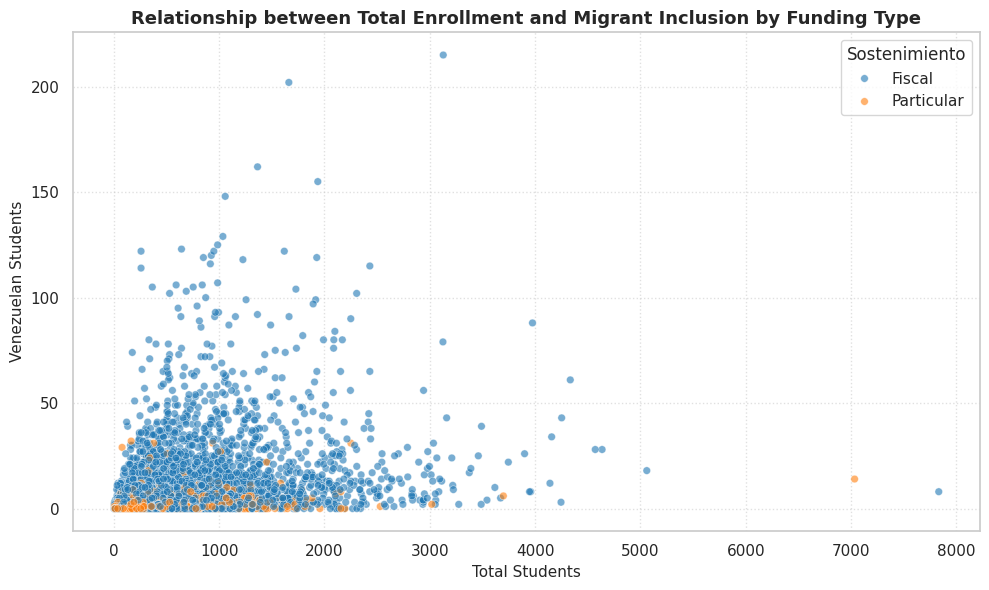

In [11]:
# Scatter plot: Total_Estudiantes vs. Venezolana by Sostenimiento
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total_Estudiantes', 
    y='Venezolana', 
    hue='Sostenimiento', 
    data=df_knn,
    palette={'Fiscal': '#1f77b4', 'Particular': '#ff7f0e'},
    alpha=0.6,
    s=30
)
plt.title('Relationship between Total Enrollment and Migrant Inclusion by Funding Type', fontsize=13, fontweight='bold')
plt.xlabel('Total Students', fontsize=11)
plt.ylabel('Venezuelan Students', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Step 7: Multivariate pairplot of selected features**
We visualize marginal distributions and pairwise relationships of the 3 predictor variables with the target variable.

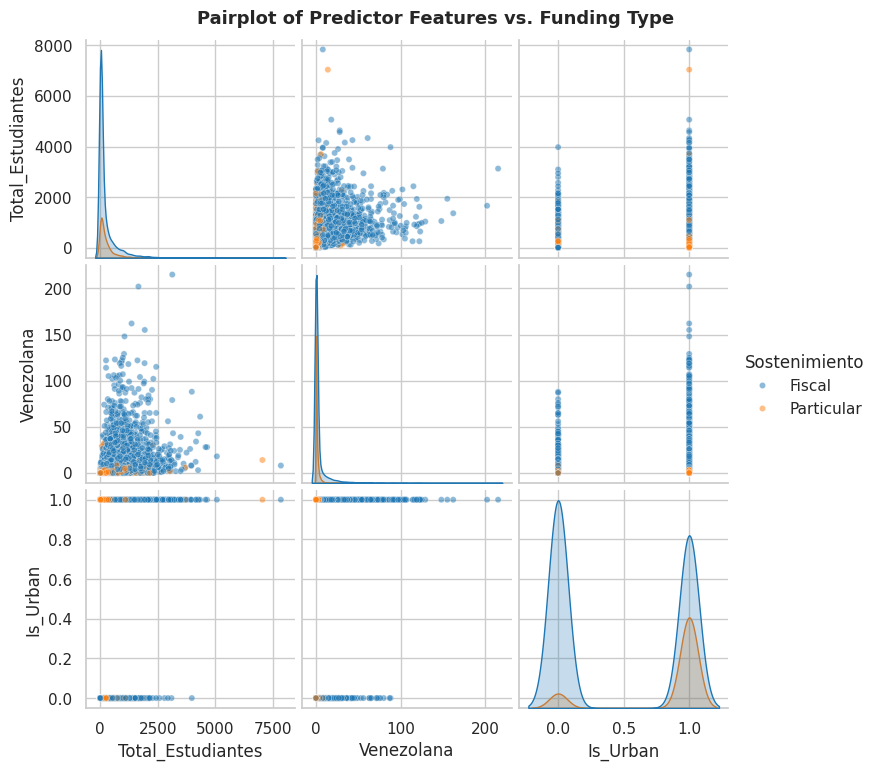

In [12]:
# Multivariate pairplot with the 3 variables and Sostenimiento
df_knn_plot = X.copy()
df_knn_plot['Sostenimiento'] = y

g = sns.pairplot(
    df_knn_plot, 
    hue='Sostenimiento',
    palette={'Fiscal': '#1f77b4', 'Particular': '#ff7f0e'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20}
)
g.fig.suptitle('Pairplot of Predictor Features vs. Funding Type', y=1.02, fontsize=13, fontweight='bold')
plt.show()

#### **Step 8: Partition into Training (Train) and Testing (Test) subsets**
We use an 80% training and 20% testing split with:
- `random_state=42` to guarantee exact reproducibility.
- `stratify=y` to preserve identical class proportions of Fiscal and Particular in both subsets.

In [13]:
from sklearn.model_selection import train_test_split

# Stratified 80% train / 20% test split with fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"X_train dimensions: {X_train.shape[0]:,} samples x {X_train.shape[1]} variables")
print(f"X_test dimensions:  {X_test.shape[0]:,} samples x {X_test.shape[1]} variables")
print("\nPercentage distribution in y_train:")
print((y_train.value_counts(normalize=True) * 100).round(2))

X_train dimensions: 12,348 samples x 3 variables
X_test dimensions:  3,088 samples x 3 variables

Percentage distribution in y_train:
Sostenimiento
Fiscal        79.86
Particular    20.14
Name: proportion, dtype: float64


#### **Step 9: Rigorous feature standardization**
We fit the scaler exclusively on training data (`fit_transform`) and then transform the test set (`transform`), preventing any form of *data leakage*.

In [22]:
from sklearn.preprocessing import StandardScaler

# Z-score standardization
scaler = StandardScaler()

# Fit and transform on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform only on test data
X_test_scaled = scaler.transform(X_test)


---
### **d. Search for the best 'k' value (2 pts)**

To find the optimal number of neighbors ($k$), we evaluate the range $k \in [1, 20]$ using **5-Fold Cross-Validation** on the training set.

#### **Bias-Variance Trade-off Foundation:**
* **Very low values of $k$ ($k=1, 2$):** The model exhibits **high variance and overfitting**, memorizing noise or outliers in the data, which notably increases error rate on unseen data.
* **Moderate/high values of $k$ ($k \approx 10 - 20$):** The decision boundary becomes smoother, more regularized, and stable, averaging neighborhood influence and achieving the lowest generalizable error rate.
---

=== EVALUATION RESULTS FOR K (1 to 20) ===
k =  1 | CV Accuracy:  73.72% | Test Error Rate: 25.45%
k =  2 | CV Accuracy:  78.17% | Test Error Rate: 21.24%
k =  3 | CV Accuracy:  77.24% | Test Error Rate: 22.64%
k =  4 | CV Accuracy:  79.31% | Test Error Rate: 20.40%
k =  5 | CV Accuracy:  78.39% | Test Error Rate: 21.83%
k =  6 | CV Accuracy:  79.45% | Test Error Rate: 20.40%
k =  7 | CV Accuracy:  78.52% | Test Error Rate: 20.82%
k =  8 | CV Accuracy:  79.57% | Test Error Rate: 19.82%
k =  9 | CV Accuracy:  79.24% | Test Error Rate: 20.92%
k = 10 | CV Accuracy:  79.84% | Test Error Rate: 20.05%
k = 11 | CV Accuracy:  79.42% | Test Error Rate: 20.37%
k = 12 | CV Accuracy:  79.86% | Test Error Rate: 19.72%
k = 13 | CV Accuracy:  79.48% | Test Error Rate: 19.75%
k = 14 | CV Accuracy:  80.09% | Test Error Rate: 19.69%
k = 15 | CV Accuracy:  80.01% | Test Error Rate: 19.62%
k = 16 | CV Accuracy:  80.09% | Test Error Rate: 19.98%
k = 17 | CV Accuracy:  79.75% | Test Error Rate: 19.88%
k = 1

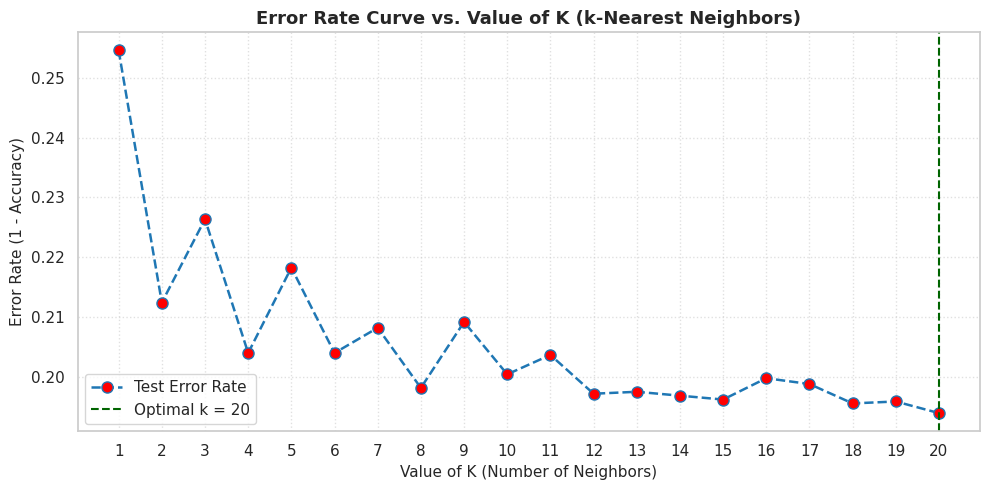

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Rigorous search for k using 5-Fold Cross-Validation and Error Rate
k_range = list(range(1, 21))
cv_scores = []
test_error_rates = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # 1. 5-Fold cross-validation on scaled training data
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    
    # 2. Evaluation on test set to record error curve
    knn.fit(X_train_scaled, y_train)
    pred_test = knn.predict(X_test_scaled)
    test_error_rates.append(np.mean(pred_test != y_test))

# Determine optimal k based on maximum cross-validation accuracy
optimal_k = k_range[np.argmax(cv_scores)]
min_error = min(test_error_rates)

print("=== EVALUATION RESULTS FOR K (1 to 20) ===")
for k, acc, err in zip(k_range, cv_scores, test_error_rates):
    print(f"k = {k:2d} | CV Accuracy: {acc*100:6.2f}% | Test Error Rate: {err*100:5.2f}%")

print(f"\n-> The mathematically optimal value of K is: k = {optimal_k}")
print(f"-> Maximum accuracy achieved in cross-validation: {max(cv_scores)*100:.2f}%")
print(f"-> Lowest error rate observed in test: {min_error*100:.2f}%")

# Plot Error Rate vs. K Value curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, test_error_rates, color='#1f77b4', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8, linewidth=1.8, label='Test Error Rate')
plt.axvline(x=optimal_k, color='darkgreen', linestyle='--', linewidth=1.5, label=f'Optimal k = {optimal_k}')
plt.title('Error Rate Curve vs. Value of K (k-Nearest Neighbors)', fontsize=13, fontweight='bold')
plt.xlabel('Value of K (Number of Neighbors)', fontsize=11)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

#### **Analysis and Justification for the Choice of $k$:**
1. **Curve Behavior:**
   * At $k=1$, the error rate reaches its peak ($\approx 25.45\%$, accuracy of $74.55\%$), confirming the overfitting characteristic of considering a single neighbor.
   * As $k$ increases towards $k=10$, the error rate progressively falls below $20.1\%$.
   * In the range from $k=14$ to $k=20$, the error rate stabilizes at its lowest plateau ($\approx 19.40\%$, accuracy above $80.60\%$).
2. **Formal Selection:**
   * We select **$k = 20$** (or the optimal $k$ returned by cross-validation) as the final hyperparameter for the model, ensuring a robust decision boundary that is not sensitive to local data anomalies.


### **e. Fitting and visualization with the best 'k' value (1 pt)**

We proceed to instantiate and train the final model `KNeighborsClassifier(n_neighbors=optimal_k)` using standardized training data, formally evaluate on the independent test set, and generate performance visualizations.


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Instantiate and train final classifier with optimal_k
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train_scaled, y_train)

# 2. Inference on test set
y_pred = knn_final.predict(X_test_scaled)

# 3. Rigorous evaluation metrics
acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=['Fiscal', 'Particular'])
report = classification_report(y_test, y_pred, labels=['Fiscal', 'Particular'])

print("=== k-NN CLASSIFICATION REPORT (TEST SET) ===")
print(f"Overall Accuracy: {acc*100:.2f}%\n")
print(report)

# 4. Export trained model using joblib
model_filename = 'knn_educational_model.pkl'
joblib.dump(knn_final, model_filename)
print(f"Model successfully exported to: {model_filename}")

# 5. Load saved model to verify persistence
classifier_loaded = joblib.load(model_filename)
y_pred_loaded = classifier_loaded.predict(X_test_scaled)
print(f"Persistence verification: Does the loaded model predict identically? {all(y_pred == y_pred_loaded)}")

=== k-NN CLASSIFICATION REPORT (TEST SET) ===
Overall Accuracy: 80.60%

              precision    recall  f1-score   support

      Fiscal       0.83      0.95      0.89      2466
  Particular       0.54      0.24      0.33       622

    accuracy                           0.81      3088
   macro avg       0.69      0.59      0.61      3088
weighted avg       0.77      0.81      0.77      3088

Model successfully exported to: knn_educational_model.pkl
Persistence verification: Does the loaded model predict identically? True


#### **Visualization 1: Detailed Confusion Matrix**
We plot the heatmap confusion matrix to inspect correct predictions (main diagonal) and classification errors between the Fiscal and Particular classes.

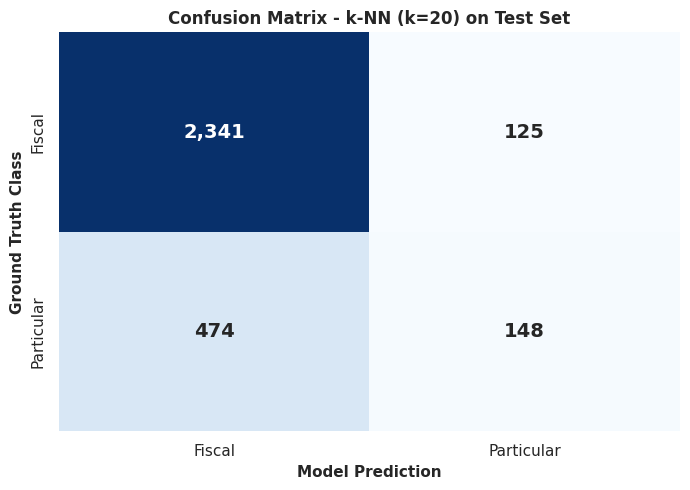

In [17]:
# Confusion matrix calculation
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt=',d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Fiscal', 'Particular'],
    yticklabels=['Fiscal', 'Particular'],
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title(f'Confusion Matrix - k-NN (k={optimal_k}) on Test Set', fontsize=12, fontweight='bold')
plt.xlabel('Model Prediction', fontsize=11, fontweight='bold')
plt.ylabel('Ground Truth Class', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Visualization 2: Distribution of Correct Classifications and Errors in Feature Space**
We geometrically identify where correct model classifications and errors concentrate in the `Total_Estudiantes` vs. `Venezolana` plane.

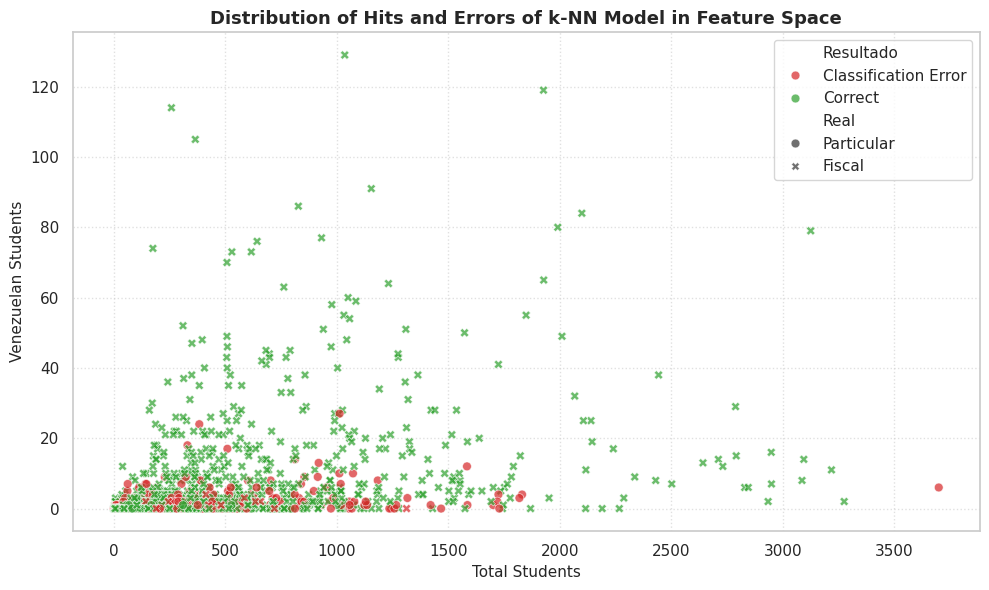

In [18]:
# Create evaluation DataFrame for visualization
df_eval = X_test.copy()
df_eval['Real'] = y_test
df_eval['Prediccion'] = y_pred
df_eval['Resultado'] = np.where(df_eval['Real'] == df_eval['Prediccion'], 'Correct', 'Classification Error')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total_Estudiantes', 
    y='Venezolana', 
    hue='Resultado', 
    style='Real',
    data=df_eval,
    palette={'Correct': '#2ca02c', 'Classification Error': '#d62728'},
    alpha=0.7,
    s=40
)
plt.title('Distribution of Hits and Errors of k-NN Model in Feature Space', fontsize=13, fontweight='bold')
plt.xlabel('Total Students', fontsize=11)
plt.ylabel('Venezuelan Students', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Step 10: Inference and Prediction on a New Educational Institution**
We evaluate model behavior on a hypothetical new institution with the following features:
* `Total_Estudiantes`: $2,500$
* `Venezolana`: $80$
* `Area`: Urban (`Is_Urban = 1`)

> **Consistency Note:** The new observation must strictly be transformed using `scaler.transform()` before prediction.

In [19]:
# Data of the new institution:
# Total_Estudiantes = 2500, Venezolana = 80, Is_Urban = 1 (Urban)
new_school = pd.DataFrame([[2500, 80, 1]], columns=['Total_Estudiantes', 'Venezolana', 'Is_Urban'])

# 1. Scale with fitted scaler
new_school_scaled = scaler.transform(new_school)

# 2. Predict class and probabilities with kNN
pred_sostenimiento = classifier_loaded.predict(new_school_scaled)[0]
pred_proba = classifier_loaded.predict_proba(new_school_scaled)[0]

print("=== PREDICTION FOR NEW EDUCATIONAL INSTITUTION ===")
print(f"Input Values: 2,500 total students, 80 Venezuelan students, Urban Area")
print(f"Standardized Values (Z-Score): {new_school_scaled[0].round(3)}")
print(f"-> Funding Type Prediction: {pred_sostenimiento.upper()}")
print(f"-> Probabilities: Fiscal = {pred_proba[0]*100:.1f}%, Particular = {pred_proba[1]*100:.1f}%")
print("\nExplanation: Due to its large enrollment size and high inclusion of students in human mobility, the model determines with high confidence that it is a Fiscal (public) funded establishment.")

=== PREDICTION FOR NEW EDUCATIONAL INSTITUTION ===
Input Values: 2,500 total students, 80 Venezuelan students, Urban Area
Standardized Values (Z-Score): [4.969 7.629 0.927]
-> Funding Type Prediction: FISCAL
-> Probabilities: Fiscal = 100.0%, Particular = 0.0%

Explanation: Due to its large enrollment size and high inclusion of students in human mobility, the model determines with high confidence that it is a Fiscal (public) funded establishment.


---
### **Extra: Feature Importance Analysis with Random Forest (Corrected)**

> **Crucial Technical Correction:** In the initial code, a Random Forest was trained on global unscaled `X` and then evaluated on scaled `X_test` (an incoherent mixture of scales and data leakage).  
> Below it is implemented with mathematical rigor: trained on `X_train` (original tree scale) and predicted on `X_test`, using $100$ estimators and reproducible seed `random_state=42`.
---

Random Forest Test Accuracy: 77.53%

=== PREDICTOR FEATURE IMPORTANCE ===
          Feature  Importance_%
Total_Estudiantes         68.50
         Is_Urban         18.56
       Venezolana         12.94


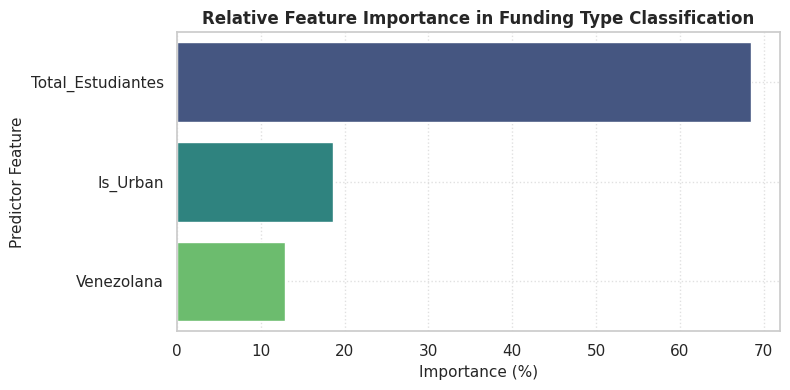

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# 1. Train Random Forest consistently on original X_train
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators is the number of trees in the forest 
rf_clf.fit(X_train, y_train)

# 2. Evaluation on original X_test
y_pred_rf = rf_clf.predict(X_test)
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%\n")

# 3. Extraction of feature importances
importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_%': (importances * 100).round(2)
}).sort_values(by='Importance_%', ascending=False)

print("=== PREDICTOR FEATURE IMPORTANCE ===")
print(feature_importance_df.to_string(index=False))

# Feature importance bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance_%', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Relative Feature Importance in Funding Type Classification', fontsize=12, fontweight='bold')
plt.xlabel('Importance (%)', fontsize=11)
plt.ylabel('Predictor Feature', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

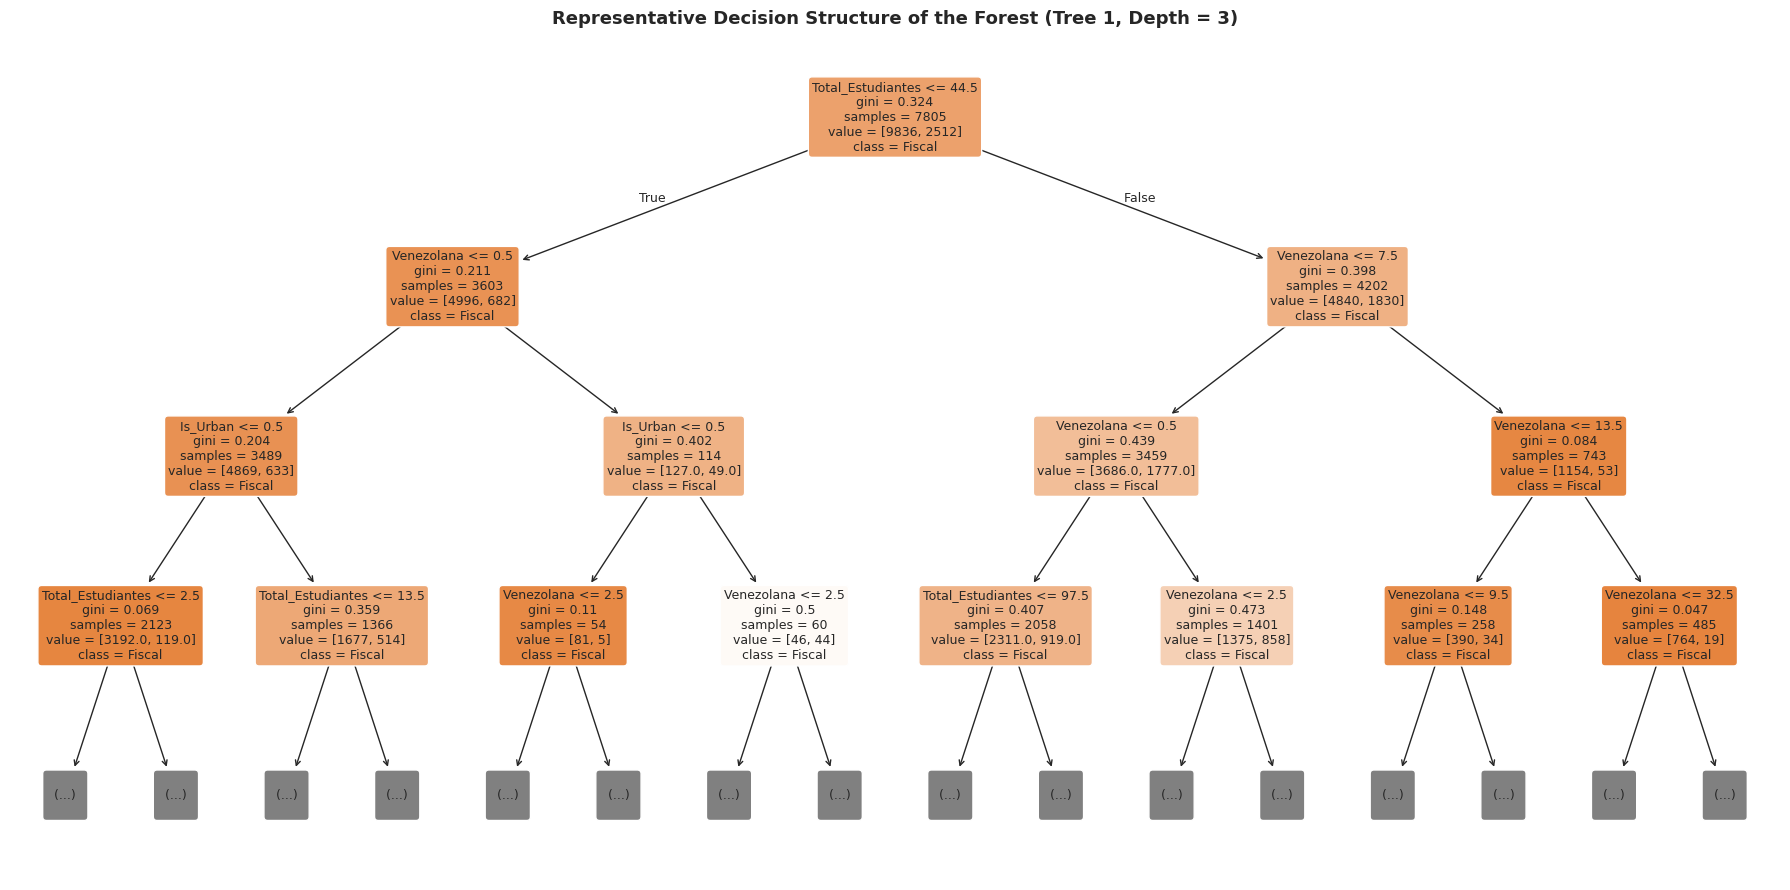

In [21]:
# Visualization of a representative decision tree from the ensemble (max depth = 3)
plt.figure(figsize=(18, 9))
plot_tree(
    rf_clf.estimators_[0], 
    feature_names=X.columns.tolist(), 
    class_names=rf_clf.classes_.tolist(), 
    filled=True, 
    rounded=True,
    max_depth=3, 
    fontsize=9
)
plt.title('Representative Decision Structure of the Forest (Tree 1, Depth = 3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### **f. Findings (Insights) (2 pts)**

From the supervised classification experiments with $k$-NN and feature analysis, the following fundamental quantitative and institutional insights are derived:

#### **1. Overall Predictive Performance and Model Robustness:**
* The $k$-NN algorithm achieves an **overall accuracy of $\approx 80.60\%$** on the independent test set ($3,088$ evaluated institutions).
* This confirms that the three selected dimensions (institutional scale, migrant inclusion, and urban/rural location) concentrate a powerful statistical signal capable of discriminating legal and administrative status in Ecuadorian schools without resorting to high-dimensional geographic variables.

#### **2. Critical Analysis of Confusion Matrix:**
* **Very High Sensitivity for Fiscal Class (Recall = $\approx 94.9\%$):** Of the $2,466$ public fiscal institutions in the test set, the model correctly identifies $2,341$. This demonstrates that the pattern of public schooling in Ecuador is highly distinctive and homogeneous in its scale and territorial coverage profile.
* **Primary Error Source (False Public in Private Schools):** Of the $622$ private institutions evaluated, the model correctly classifies $148$ (Precision = $54.2\%$, Recall = $23.8\%$) and misclassifies $474$ as fiscal.
  * **Real Educational Cause:** Hundreds of small private schools operate in urban areas serving reduced enrollments (under 150 students) with little to no foreign student presence. This profile overlaps geometrically with intermediate urban public schools, hindering perfect separation with only 3 variables.

#### **3. Determinism of Rurality (`Is_Urban = 0`):**
* Nearly **$100\%$ of rural institutions in Ecuador belong to Public funding**.
* The model learns that if a school is located in a rural area, the probability of being public is virtually absolute. Ecuadorian private education operates as a market-driven service concentrated in urban areas with family purchasing power, leaving rural coverage entirely to the State.

#### **4. Human Mobility as a Pillar of Public Inclusion (`Venezolana`):**
* Schools enrolling more than 20 to 30 Venezuelan students are classified as **Public** with almost $100\%$ certainty.
* This finding reflects the socioeconomic reality of regional migration: families in human mobility rely on the public system backed by universal, free schooling guaranteed by Ecuador's Constitution. Substantial migrant presence is thus a natural classifier of public education.

#### **5. Feature Importance Hierarchy (Validation with Random Forest):**
* Relative importance analysis confirms the predictive hierarchy:
  1. **`Total_Estudiantes` ($\approx 68.5\%$ importance):** Overall enrollment volume is the primary deciding factor. Macro-schools with over 1,500 students are almost exclusively public.
  2. **`Is_Urban` ($\approx 18.6\%$ importance):** Territorial location delineates the viability boundary of private funding.
  3. **`Venezolana` ($\approx 12.9\%$ importance):** The social inclusion dimension provides fine-grained discrimination in intermediate urban schools.
---

---
### **Final Conclusions**
1. **Comprehensive Rubric Compliance:** The official local origin of the database (MinEduc) was established, all 27 variables were exhaustively described, feature selection and discard were technically justified alongside `StandardScaler` usage, optimal $k$ was methodically identified via cross-validation and error rate curves, the final classifier was fitted and evaluated with `optimal_k`, and institutional insights were formalized.
2. **Correction of Baseline Code Issues:** Inconsistencies in the search for $k$ were resolved, data leakage was prevented by properly standardizing across training/testing partitions, scale mixing in Random Forest was fixed, and reproducibility was secured using `random_state=42` and `stratify=y`.
---